# Pairwise Agreement Matrix

In [1]:
#%%
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import pandas as pd
import numpy as np
from functools import partial
from pathlib import Path
import logging
import itertools

from monoculture.analysis.setup import ACS_TASKS, TABLESHIFT_TASKS
from monoculture.analysis.utils import (
    prettify_model_name,
    key_to_model,
    get_size_and_it,
    load_model_outputs_same_prompt,
    get_metric,
    load_task_data,
)

from monoculture.analysis.metrics import (
    matrix_pairwise_evals,
    observed_agreement_wrapper,
    ratio_agreement_wrapper,
    diff_agreement_wrapper,
)
from monoculture.analysis.plotting import plot_agreement_matrix

In [3]:
plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

TASKS = [
    "ACSIncome",
    "ACSEmployment",
    "BRFSS_Blood_Pressure",
]  # ACS_TASKS + TABLESHIFT_TASKS
print("tasks", TASKS)

RESULTS_ROOT_DIR = Path("./results/")
results_df_path = RESULTS_ROOT_DIR / "overview_results_by_prompt_style.csv"
FIGURES_ROOT_DIR = RESULTS_ROOT_DIR / "figures/"

data = None

tasks ['ACSIncome', 'ACSEmployment', 'BRFSS_Blood_Pressure']


## Load predictions

In [4]:
num_shots = 0
threshold_fitted = 1

df = pd.read_csv(results_df_path)
# restrict to zero-shot and same prompt style
df_same_prompt = df[
    (df["num_shots"] == num_shots)
    & (df["prompt_format"] == "bullet")
    & (df["prompt_connector"] == "is")
    & (df["prompt_granularity"] == "original")
    & (df["prompt_feature_order"] == "default")
    & (df["threshold_fitted"] == threshold_fitted)
]
df_same_prompt.head()

,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,prompt_granularity,prompt_feature_order,eval_results_path,predictions_path
1,ACSIncome,meta-llama--Meta-Llama-3.2-1B-Instruct,1,1,0.776744,0.680409,3019759728,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...
2,ACSIncome,allenai--OLMo-2-1124-7B-Instruct,1,1,0.904552,0.727768,3118177042,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-allenai--O...,results/folktexts/0-bullet-is/model-allenai--O...
4,ACSIncome,google--gemma-2-27b,0,1,0.438475,0.510381,3621160589,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
6,ACSIncome,google--gemma-2-27b-it,1,1,0.867235,0.659718,1712994131,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
9,ACSIncome,meta-llama--Meta-Llama-3-70B,0,1,0.532134,0.763641,4121241683,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...


In [5]:
print(df_same_prompt.shape)
assert set(TASKS).issubset(
    set(df_same_prompt["task"].unique())
), "Results for all tasks to be analysed have to be available."

(288, 14)


In [6]:
risk_scores = load_model_outputs_same_prompt(
    df_same_prompt, tasks=TASKS, return_risk_scores=True
)
predictions_all = load_model_outputs_same_prompt(
    df_same_prompt, tasks=TASKS, return_risk_scores=False
)

metrics = [
    "n_samples",
    "accuracy",
    "fpr",
    "ppr",
    "num_pred_negatives",
    "num_pred_positives",
    "balanced_accuracy",
]
for metric in metrics:
    df_same_prompt[metric] = (
        df_same_prompt["eval_results_path"]
        .apply(partial(get_metric, metric=metric))
        .copy()
    )

evals_per_task = {}  # [task][metric][model]
for task in df_same_prompt["task"].unique():
    df_task = df_same_prompt[df_same_prompt["task"] == task]
    evals_per_task[task] = {
        metric: {model: val for model, val in zip(df_task["model"], df_task[metric])}
        for metric in metrics
    }

/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_54134/3355898873.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_same_prompt[metric] = (
/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_54134/3355898873.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_same_prompt[metric] = (
/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_54134/3355898873.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

## Agreement at random - some notes

How often do models agree in the predictions they make? 
- **Note**: models that are more accuracte are also more likely to agree just by random chance
- We can correct for it
    - by deviding: report the factor by which the observation deviated
    - by substracting: report absolute deviation of observed from expected 
- When risk scores are turned into predictions not by their fitted threshold, but by cutting of at 0.5, we observe that in particular smaller models agree a lot, mainly because they are (almost) constant predictors. This highlights, that a deeper look into a model's behaviour is needed to explain the agreement rates (take model behavior into account). 

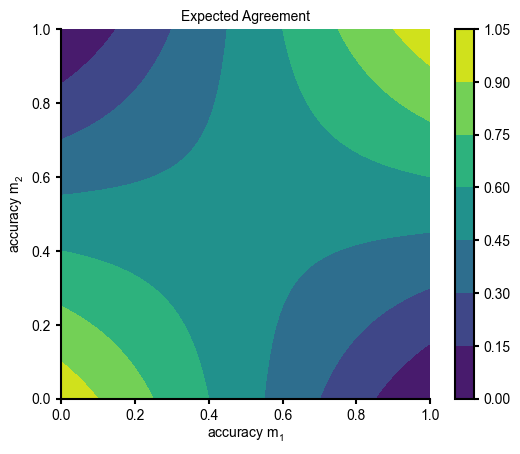

In [7]:
fun = lambda a1, a2: a1 * a2 + (1 - a1) * (1 - a2)
vals = np.arange(0, 1.01, step=0.01)
xs, ys = np.meshgrid(vals, vals)
zs = xs * ys + (1 - xs) * (1 - ys)
plt.contourf(vals, vals, zs)
plt.axis("scaled")
plt.xlabel("accuracy $m_1$")
plt.ylabel("accuracy $m_2$")
plt.title("Expected Agreement")
plt.colorbar()
plt.show()
# cut-through
# plt.plot(vals, [fun(v,1-v) for v in vals])

## Restrict analysis to models based on performance or true labels?

In [8]:
restrict_to_better_const = False
restrict_to_base_models = False
restrict_to_it_models = False
restrict_to_positive_label = False
restrict_to_negative_label = False
assert not (
    restrict_to_positive_label & restrict_to_negative_label
), "Choose one or none."
assert not (restrict_to_base_models & restrict_to_it_models), "Choose one or none."

predictions = predictions_all.copy()


if any(
    [restrict_to_better_const, restrict_to_positive_label, restrict_to_negative_label]
):
    if not data:
        logging.warning("Load task data")
        data = load_task_data(TASKS, Path("./data"))

    for task in TASKS:
        df_task = df_same_prompt[df_same_prompt["task"] == task]
        y_true = data[task][1]

        if restrict_to_better_const:
            const_acc = max((y_true == 1).sum(), (y_true == 0).sum()) / y_true.shape[0]
            models_better_const = sorted(
                df_task["model"][df_task["accuracy"] > const_acc].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models_better_const)

        if restrict_to_negative_label or restrict_to_positive_label:
            filter_idx = y_true[y_true == int(restrict_to_positive_label)].index
            predictions[task] = predictions[task].loc[filter_idx]
        print(task, predictions[task].shape)


if any([restrict_to_base_models, restrict_to_it_models]):
    for task in TASKS:
        models_filtered = list(
            df_same_prompt[
                df_same_prompt.apply(
                    lambda row: (row.task == task)
                    & (row.model in predictions[task].columns)
                    & (row.is_inst == int(restrict_to_it_models)),
                    axis=1,
                )
            ]["model"].unique()
        )
        predictions[task] = predictions[task].filter(items=models_filtered)
        print(task, predictions[task].shape)

**issue**: When looking only at the fraction of individuals models agree in predicting 0/1, the base rate (all individuals seems wrong, shouldn't it be only among those that receive at least one such prediction?)

## Pairwise Agreement Matrix


### Observed

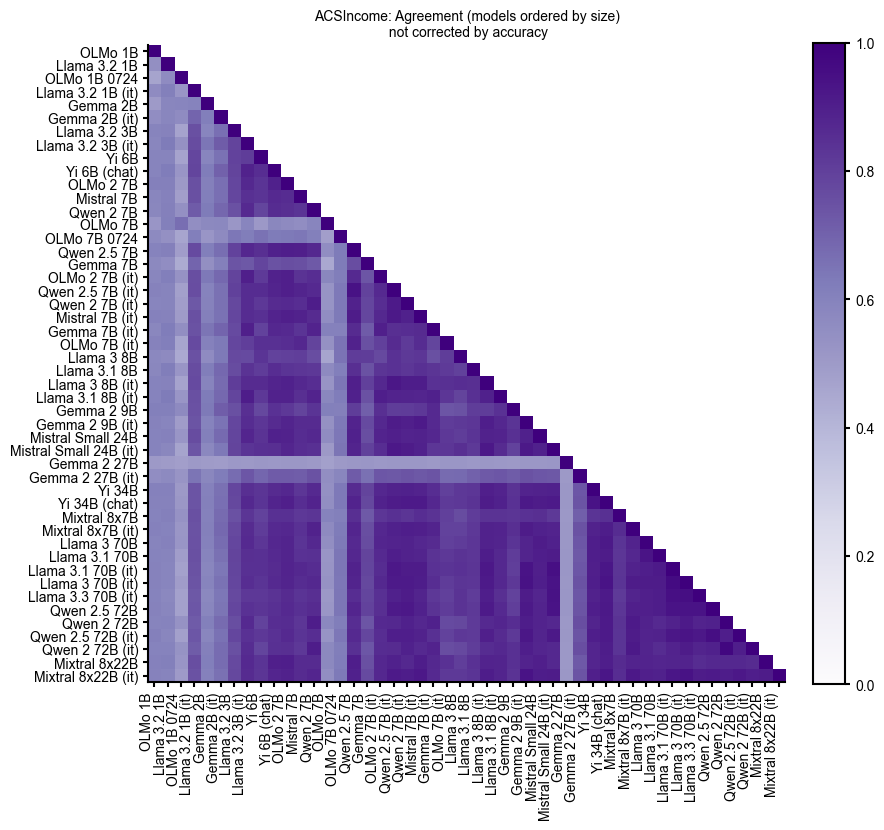

min: 0.44	max: 1.00


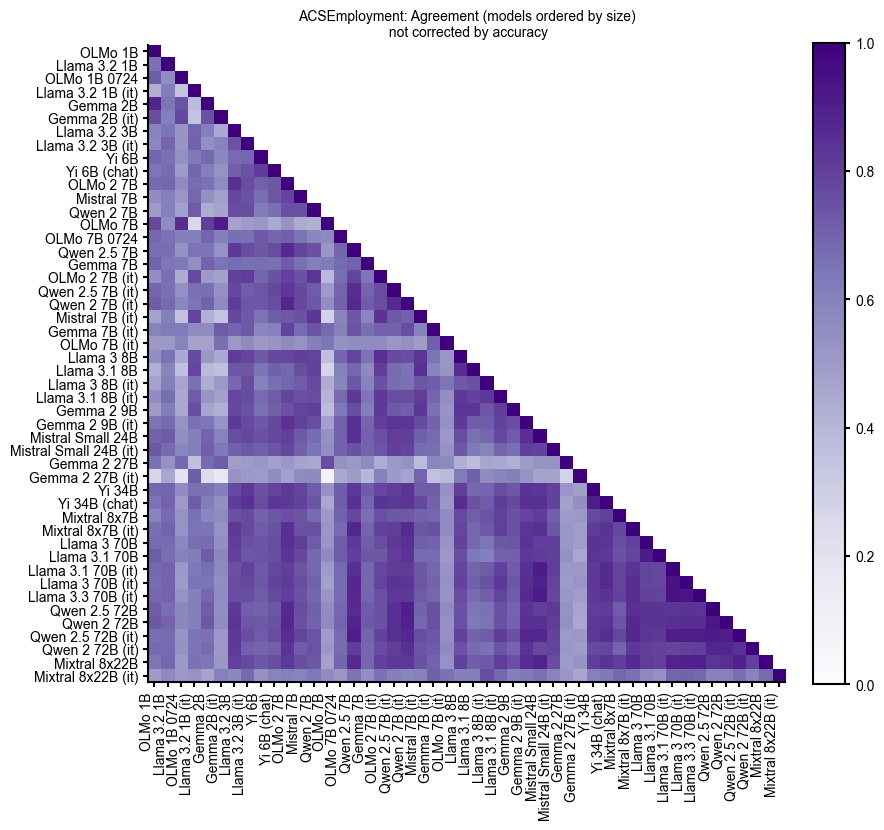

min: 0.07	max: 1.00


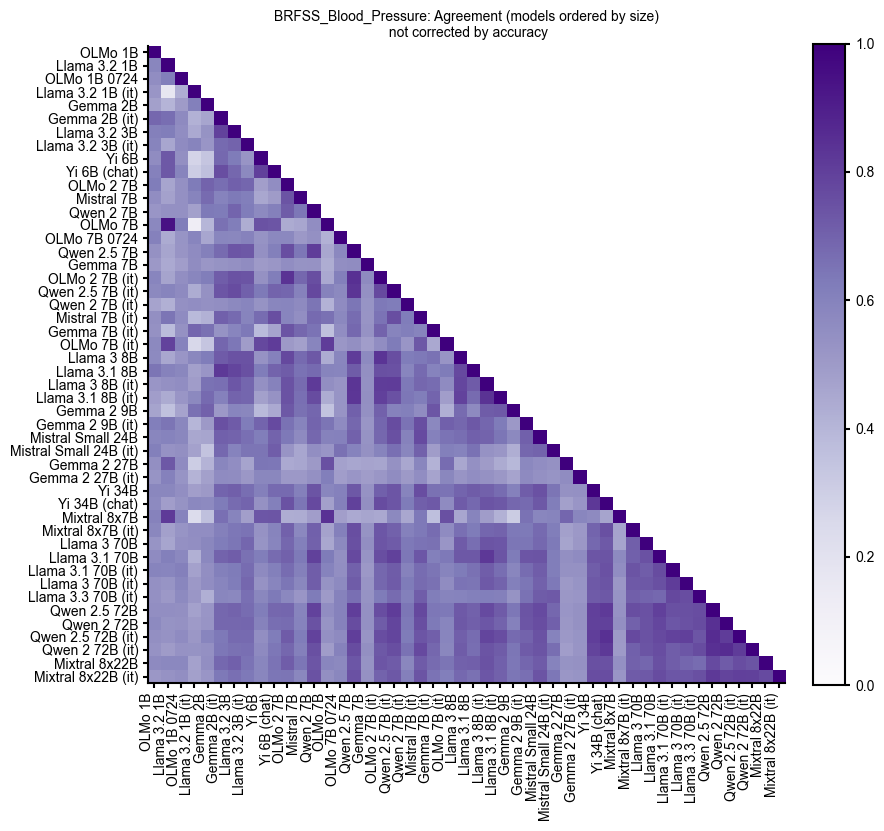

min: 0.12	max: 1.00


In [9]:
# agreement not corrected by accuracy
# 1 = full agreement, 0 = no agreement/exaclty opposite, midpoint unclear, thus unicolor
for task in TASKS:
    models_sorted = sorted(predictions[task].columns, key=get_size_and_it)
    agreement_matrix = matrix_pairwise_evals(
        models_sorted,
        partial(observed_agreement_wrapper, predictions=predictions[task]),
    )

    cmap_bound = max(
        abs(agreement_matrix[~agreement_matrix.isnan()].min()),
        abs(agreement_matrix[~agreement_matrix.isnan()].max()),
    )
    plot_agreement_matrix(
        models_sorted,
        agreement_matrix,
        cmap="Purples",
        title=f"{task}: Agreement (models ordered by size)\n not corrected by accuracy",
        figsize=(9, 9),
        annotate=False,
    )
    print(
        f"min: {agreement_matrix[~agreement_matrix.isnan()].min():.2f}\tmax: {agreement_matrix[~agreement_matrix.isnan()].max():.2f}"
    )

### Ratio Obs/Exp

When calculating the ratio between the observed agreement and what we would expect given the accuracy of each model (i.e. assuming models make their errors at random), we see that model predictions, especially for smaller models are much more aligned than what we would expect at random. 
- values close to 1 mean that model agreement is on a level close to what we would expect at random
- dark blue cells indicate that model pairs agree much less than what would be expected at random (anti-correlated?)
- dark red cells indicate that model pairs agree much more than random

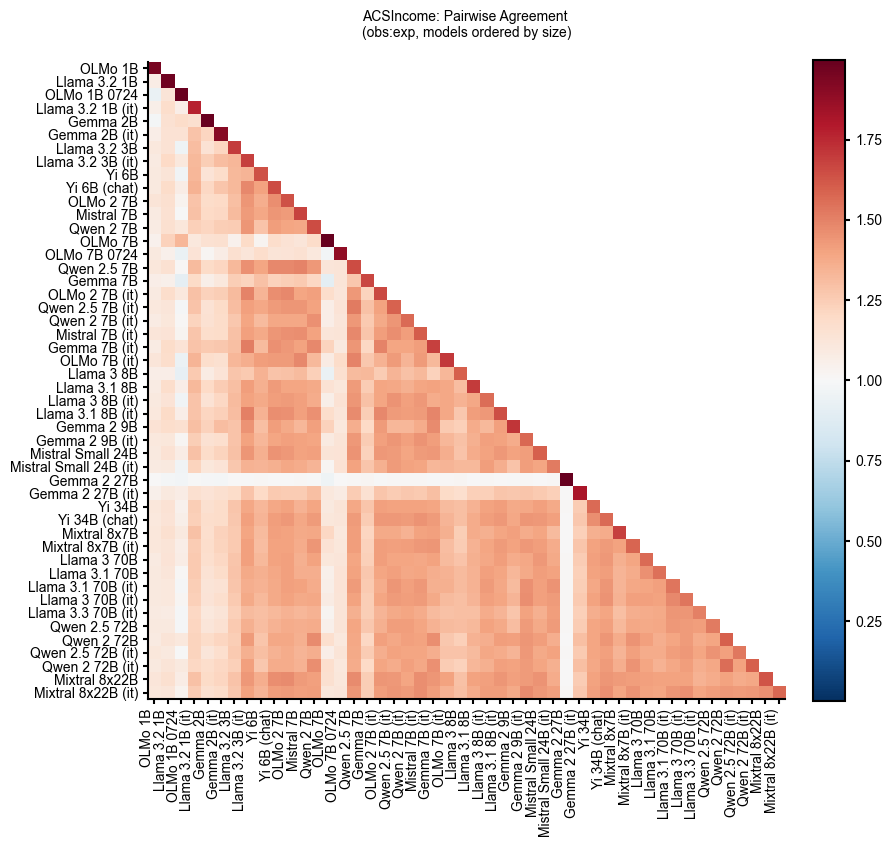

min: 0.90	max: 2.00	median: 1.34


In [10]:
# ratio
for task in ["ACSIncome"]:
    models_sorted = sorted(predictions[task].columns, key=get_size_and_it)
    agreement_matrix = matrix_pairwise_evals(
        models_sorted,
        partial(
            ratio_agreement_wrapper,
            predictions=predictions[task],
            evals=evals_per_task[task],
        ),
    )

    cmap_bound = max(
        abs(agreement_matrix[~agreement_matrix.isnan()].min()),
        abs(agreement_matrix[~agreement_matrix.isnan()].max()),
    )
    diff_to_1 = 1 - cmap_bound
    plot_agreement_matrix(
        models_sorted,
        agreement_matrix,
        cmap="RdBu_r",
        title=f"{task}: Pairwise Agreement \n(obs:exp, models ordered by size)\n",
        figsize=(9, 9),
        annotate=False,
        vmin=1 - diff_to_1,
        vmax=1 + diff_to_1,
    )
    print(
        f"min: {agreement_matrix[~agreement_matrix.isnan()].min():.2f}\tmax: {agreement_matrix[~agreement_matrix.isnan()].max():.2f}\tmedian: {agreement_matrix[~agreement_matrix.isnan()].median():.2f}"
    )

### Diff Obs - Exp

When calculating the difference between the observed and expected agreement, we see that model predictions tend to be more aligned than what we would expect at random. 
- values close to 0 mean that model agreement is on a level close to what we would expect at random
- dark blue cells indicate that model pairs agree much less than what would be expected at random (anti-correlated?)
- dark red cells indicate that model pairs agree much more than random

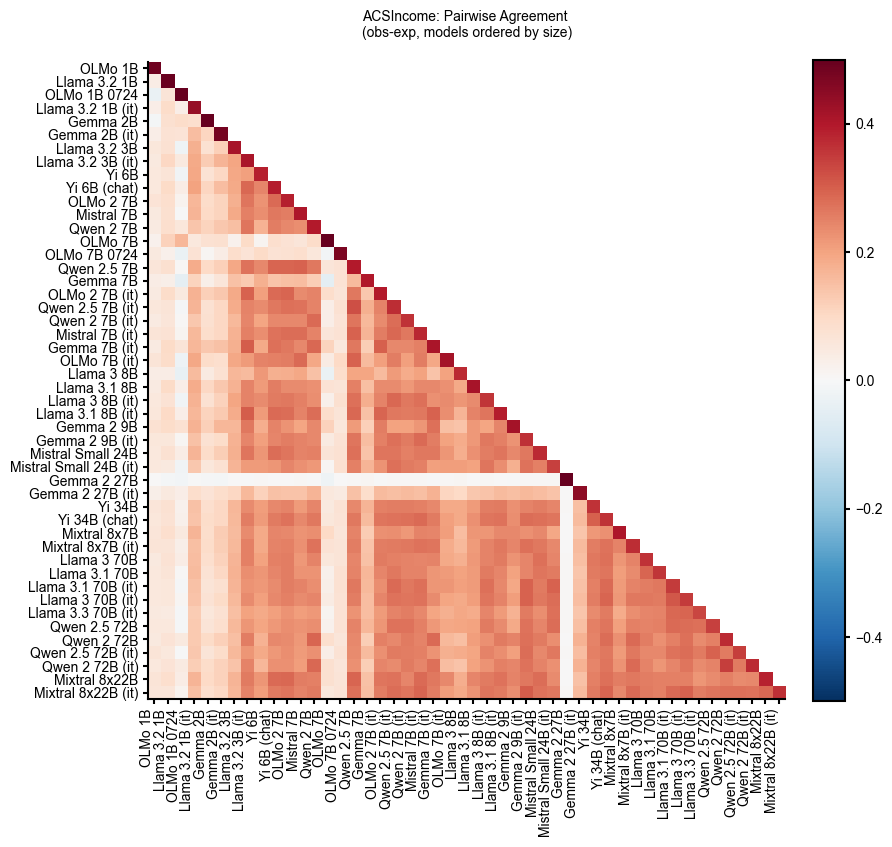

min: -0.05	max: 0.50	median: 0.21


In [11]:
# diff
for task in ["ACSIncome"]:
    models_sorted = sorted(
        predictions[task].columns, key=get_size_and_it
    )  # sort_by_size_and_family(predictions[task].columns) #
    agreement_matrix = matrix_pairwise_evals(
        models_sorted,
        partial(
            diff_agreement_wrapper,
            predictions=predictions[task],
            evals=evals_per_task[task],
        ),
    )

    cmap_bound = max(
        abs(agreement_matrix[~agreement_matrix.isnan()].min()),
        abs(agreement_matrix[~agreement_matrix.isnan()].max()),
    )
    plot_agreement_matrix(
        models_sorted,
        agreement_matrix,
        cmap="RdBu_r",
        title=f"{task}: Pairwise Agreement \n(obs-exp, models ordered by size)\n",
        figsize=(9, 9),
        annotate=False,
        vmin=-cmap_bound,
        vmax=cmap_bound,
    )
    print(
        f"min: {agreement_matrix[~agreement_matrix.isnan()].min():.2f}\tmax: {agreement_matrix[~agreement_matrix.isnan()].max():.2f}\tmedian: {agreement_matrix[~agreement_matrix.isnan()].median():.2f}"
    )

## Agreement Matrix by Model Families

In [12]:
from monoculture.analysis.setup import model_families_coarse as model_families

print(model_families)


def create_model_familiy_dict(models):
    # for every model family get the corresponding models
    dict_models_per_family = {
        mf: [
            m
            for m in models_sorted
            if mf in prettify_model_name(key_to_model(m)) or mf.lower() in m.lower()
        ]
        for mf in model_families
    }

    # remove higher-generation models (in case of fine-grained families)
    if "Gemma 2" in model_families:
        dict_models_per_family["Gemma"] = [
            m
            for m in dict_models_per_family["Gemma"]
            if "Gemma 2" not in prettify_model_name(key_to_model(m))
        ]
    for llama_gen in ["Lamma 3.1", "Lamma 3.2", "Lamma 3.3"]:
        if llama_gen in model_families:
            dict_models_per_family["Llama 3"] = [
                m
                for m in dict_models_per_family["Llama 3"]
                if llama_gen not in prettify_model_name(key_to_model(m))
            ]

    # get indices of each model
    dict_modelidx_per_family = {
        mf: [models_sorted.index(m) for m in mlist]
        for mf, mlist in dict_models_per_family.items()
    }
    return dict_models_per_family


dict_models_per_family = create_model_familiy_dict(models_sorted)


def get_familiy_mean(mf1, mf2, fun):
    models_mf1 = dict_models_per_family[mf1]
    models_mf2 = dict_models_per_family[mf2]
    evals = np.array(
        [fun(m1, m2) for (m1, m2) in itertools.product(models_mf1, models_mf2)]
    )
    return evals.mean()

['Gemma', 'Llama', 'Mistral', 'OLMo', 'Qwen', 'Yi']


{'Gemma': 8, 'Llama': 13, 'Mistral': 8, 'OLMo': 7, 'Qwen': 8, 'Yi': 4}
Couldn't find prettified name for Gemma.
Couldn't find prettified name for Llama.
Couldn't find prettified name for Mistral.
Couldn't find prettified name for OLMo.
Couldn't find prettified name for Qwen.
Couldn't find prettified name for Yi.
Couldn't find prettified name for Gemma.
Couldn't find prettified name for Llama.
Couldn't find prettified name for Mistral.
Couldn't find prettified name for OLMo.
Couldn't find prettified name for Qwen.
Couldn't find prettified name for Yi.


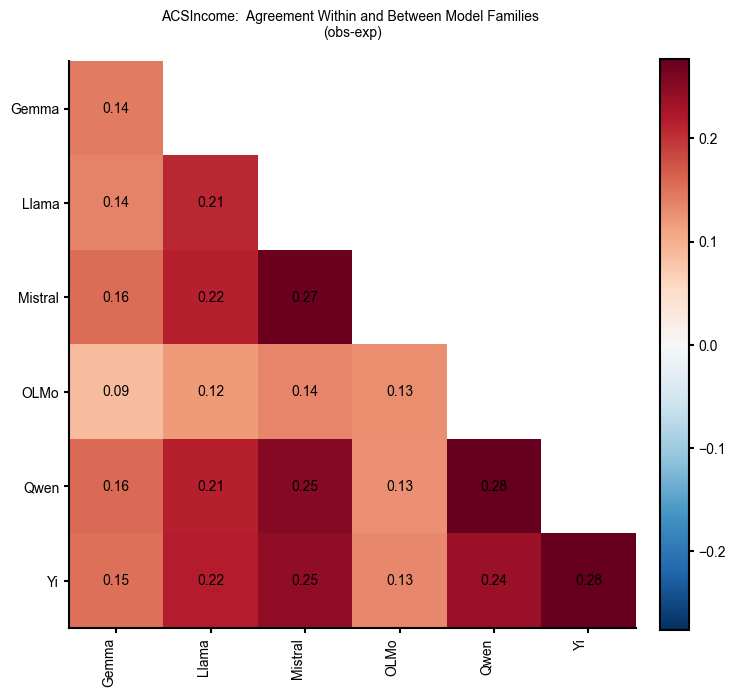

min: 0.09	max: 0.28	median: 0.16
{'Gemma': 8, 'Llama': 13, 'Mistral': 8, 'OLMo': 7, 'Qwen': 8, 'Yi': 4}
Couldn't find prettified name for Gemma.
Couldn't find prettified name for Llama.
Couldn't find prettified name for Mistral.
Couldn't find prettified name for OLMo.
Couldn't find prettified name for Qwen.
Couldn't find prettified name for Yi.
Couldn't find prettified name for Gemma.
Couldn't find prettified name for Llama.
Couldn't find prettified name for Mistral.
Couldn't find prettified name for OLMo.
Couldn't find prettified name for Qwen.
Couldn't find prettified name for Yi.


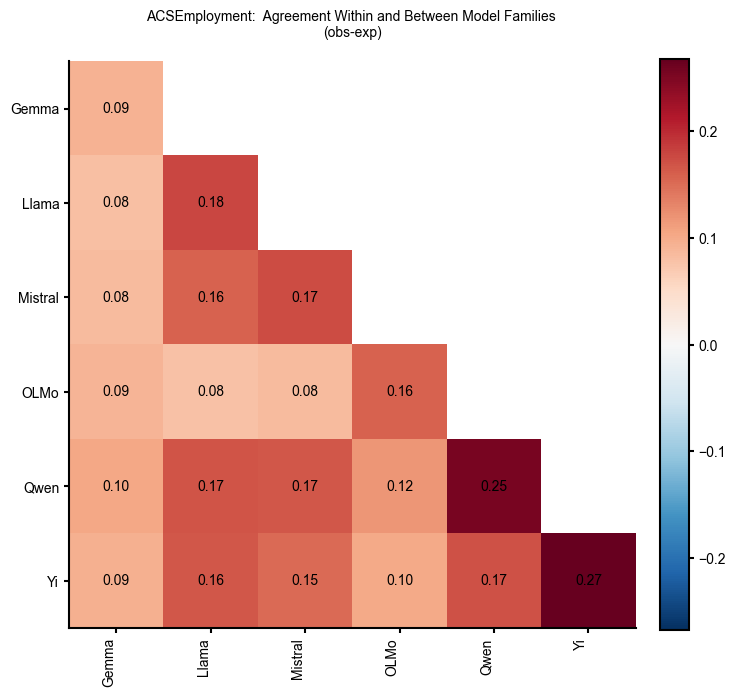

min: 0.08	max: 0.27	median: 0.15


In [13]:
for task in ["ACSIncome", "ACSEmployment"]:

    print(
        {
            family: len([m for m in models if m in predictions[task].columns])
            for family, models in dict_models_per_family.items()
        }
    )
    dict_models_per_family = create_model_familiy_dict(predictions[task].columns)

    family_matrix = matrix_pairwise_evals(
        model_families,
        partial(
            get_familiy_mean,
            fun=partial(
                diff_agreement_wrapper,
                evals=evals_per_task[task],
                predictions=predictions[task],
            ),
        ),
    )

    cmap_bound = max(
        abs(family_matrix[~family_matrix.isnan()].min()),
        abs(family_matrix[~family_matrix.isnan()].max()),
    )

    plot_agreement_matrix(
        model_families,
        family_matrix,
        cmap="RdBu_r",
        title=f"{task}:  Agreement Within and Between Model Families \n(obs-exp)\n",
        # figsize=(9, 9),
        annotate=True,
        vmin=-cmap_bound,
        vmax=cmap_bound,
    )

    print(
        f"min: {family_matrix[~family_matrix.isnan()].min():.2f}\tmax: {family_matrix[~family_matrix.isnan()].max():.2f}\tmedian: {family_matrix[~family_matrix.isnan()].median():.2f}"
    )